# Generate Report — Matched Sample (Equal APR / HPR)

Same analysis as `generate_report.ipynb` but with **equal sample sizes**: human fix PRs are randomly sampled to match the number of agent fix PRs.

**Produces:**
- `results/matched_report_figures/` — PNG figures
- `results/matched_report.txt` — text summary with tables

In [2]:
%pip install matplotlib seaborn scipy pyarrow fsspec requests lifelines

Note: you may need to restart the kernel to use updated packages.


## Imports & Setup

In [3]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats as sp_stats

%matplotlib inline

## Paths

In [4]:
DATA_DIR = Path("data_dec2024_feb2026")
OUT_DIR = Path("results")
FIG_DIR = OUT_DIR / "matched_report_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

REPORT_PATH = OUT_DIR / "matched_report.txt"

RESULTS_DIR = Path("results")

## Load Data (Fix PRs Only) — Matched Sample

In [5]:
HF_BASE = "https://huggingface.co/datasets/mabujadallah/GitHub-Agentic-PR-Dataset/resolve/main"

print("Loading fix-only data from Hugging Face ...")
all_prs_full = pd.read_parquet(f"{HF_BASE}/fix_prs_only.parquet")
commits_full = pd.read_parquet(f"{HF_BASE}/fix_pr_commits.parquet")
details_full = pd.read_parquet(f"{HF_BASE}/fix_pr_commit_details.parquet",
                               columns=["sha", "pr_id", "filename", "additions", "deletions"])

# Exclude open PRs — only keep closed PRs (merged + closed-unmerged) per Watanabe et al.
all_prs_full = all_prs_full[all_prs_full["state"] == "closed"].copy()

agent_prs_full = all_prs_full[all_prs_full["source"] == "agent"].copy()
human_prs_full = all_prs_full[all_prs_full["source"] == "human"].copy()

print(f"  Full Agent PRs (closed) : {len(agent_prs_full):,}")
print(f"  Full Human PRs (closed) : {len(human_prs_full):,}")

# ── Matched sampling: sample human PRs to match agent PR count ──
SEED = 42
n_agent = len(agent_prs_full)
human_prs_sampled = human_prs_full.sample(n=n_agent, random_state=SEED)

agent_prs = agent_prs_full.copy()
human_prs = human_prs_sampled.copy()
all_prs = pd.concat([agent_prs, human_prs], ignore_index=True)

# Filter commits and details to only matched PR ids
matched_pr_ids = set(all_prs["id"])
commits = commits_full[commits_full["pr_id"].isin(matched_pr_ids)].copy()
details = details_full[details_full["pr_id"].isin(matched_pr_ids)].copy()

print(f"\n  Matched Agent PRs : {len(agent_prs):,}")
print(f"  Matched Human PRs : {len(human_prs):,}")
print(f"  Matched Commits   : {len(commits):,}")
print(f"  Matched Details   : {len(details):,}")
print(f"  Random seed       : {SEED}")

Loading fix-only data from Hugging Face ...
  Full Agent PRs (closed) : 46,957
  Full Human PRs (closed) : 288,689

  Matched Agent PRs : 46,957
  Matched Human PRs : 46,957
  Matched Commits   : 236,451
  Matched Details   : 958,641
  Random seed       : 42


In [6]:
print("=== all_prs (matched fix PRs) ===")
display(all_prs.sample(10))

print("\n=== commits ===")
display(commits.sample(10))

print("\n=== details ===")
display(details.sample(10))

=== all_prs (matched fix PRs) ===


,id,number,title,body,user,user_id,state,created_at,closed_at,merged_at,repo_id,repo_url,repo_name,html_url,is_agent,agent,type,source
45020,2722553438,259921,Fix: Disabling a tool in a toolset disables th...,When a user disables a single tool within a to...,Copilot,198982749,closed,2025-08-05T22:22:08Z,2025-08-06T01:15:54Z,None,41881900,https://api.github.com/repos/microsoft/vscode,microsoft/vscode,https://github.com/microsoft/vscode/pull/259921,True,Copilot,fix,agent
86396,3122898127,31547,Fix Shift+click selection between chord symbol...,Resolves: #31410 <!-- Replace `NNNNN` with a G...,pyonpyoco,60975353,closed,2025-12-22T13:04:27Z,2026-01-03T00:52:01Z,2026-01-03T00:52:01Z,4454793,https://api.github.com/repos/musescore/MuseScore,musescore/MuseScore,https://github.com/musescore/MuseScore/pull/31547,False,human,fix,human
56005,2386055628,12897,[AUTO-CHERRYPICK] Patch ceph for CVE-2025-174...,This is an auto-generated pull request to cher...,CBL-Mariner-Bot,75509084,closed,2025-03-11T19:02:40Z,2025-03-19T19:27:33Z,2025-03-19T19:27:33Z,281765424,https://api.github.com/repos/microsoft/azurelinux,microsoft/azurelinux,https://github.com/microsoft/azurelinux/pull/1...,False,human,fix,human
80827,2626357650,157201,Better fix for `__index__` SymInt issue,Stack from [ghstack](https://github.com/ezyang...,jansel,533820,closed,2025-06-28T17:45:02Z,2025-07-01T07:06:49Z,None,65600975,https://api.github.com/repos/pytorch/pytorch,pytorch/pytorch,https://github.com/pytorch/pytorch/pull/157201,False,human,fix,human
10878,3242865686,34311,fix(core): handle EPIPE errors gracefully in d...,## Current Behavior\n\nWhen a client disconnec...,FrozenPandaz,8104246,closed,2026-02-03T20:41:57Z,2026-02-04T14:44:00Z,2026-02-04T14:44:00Z,100061716,https://api.github.com/repos/nrwl/nx,nrwl/nx,https://github.com/nrwl/nx/pull/34311,True,Claude_Code,fix,agent
48064,3033913419,75742,"[NoQA] Revert ""fix: adapt elf workflow to remo...",Reverts Expensify/App#75341\r\n\r\nStraight re...,mountiny,36083550,closed,2025-11-21T14:10:39Z,2025-11-21T14:17:05Z,2025-11-21T14:17:05Z,285902689,https://api.github.com/repos/Expensify/App,Expensify/App,https://github.com/Expensify/App/pull/75742,False,human,fix,human
22981,2209483166,19633,chore(sqlsmith): ignore sqrt with negative inp...,Cherry picking \#19566 onto branch release-2.1...,github-actions[bot],41898282,closed,2024-12-02T05:22:06Z,2024-12-02T05:39:15Z,2024-12-02T05:39:15Z,453068084,https://api.github.com/repos/risingwavelabs/ri...,risingwavelabs/risingwave,https://github.com/risingwavelabs/risingwave/p...,True,Cursor,fix,agent
47060,2706442946,6410,fix(components): scalar tooltip style inconsis...,**Changes**\r\n\r\nthis pr updates the scalar ...,antlio,14966155,closed,2025-07-30T09:12:49Z,2025-07-30T20:39:09Z,None,679280065,https://api.github.com/repos/scalar/scalar,scalar/scalar,https://github.com/scalar/scalar/pull/6410,False,human,fix,human
18104,3289672792,3140,fix: cargo deny,None,eyusufatik,19624533,closed,2026-02-16T11:57:10Z,2026-02-16T13:44:02Z,2026-02-16T13:44:02Z,716131429,https://api.github.com/repos/chainwayxyz/citrea,chainwayxyz/citrea,https://github.com/chainwayxyz/citrea/pull/3140,True,Copilot,fix,agent
81061,3310267800,5601,"security: fix MEDIUM findings (M2, M5, M10) an...",## Security Fixes — Batch 4\n\n### H5: eval() ...,ink-the-squid,257463439,closed,2026-02-21T05:16:03Z,2026-02-21T05:34:50Z,2026-02-21T05:34:50Z,595832198,https://api.github.com/repos/Helicone/helicone,Helicone/helicone,https://github.com/Helicone/helicone/pull/5601,False,human,fix,human


=== all_prs (matched fix PRs) ===


,id,number,title,body,user,user_id,state,created_at,closed_at,merged_at,repo_id,repo_url,repo_name,html_url,is_agent,agent,type,source
45020,2722553438,259921,Fix: Disabling a tool in a toolset disables th...,When a user disables a single tool within a to...,Copilot,198982749,closed,2025-08-05T22:22:08Z,2025-08-06T01:15:54Z,None,41881900,https://api.github.com/repos/microsoft/vscode,microsoft/vscode,https://github.com/microsoft/vscode/pull/259921,True,Copilot,fix,agent
86396,3122898127,31547,Fix Shift+click selection between chord symbol...,Resolves: #31410 <!-- Replace `NNNNN` with a G...,pyonpyoco,60975353,closed,2025-12-22T13:04:27Z,2026-01-03T00:52:01Z,2026-01-03T00:52:01Z,4454793,https://api.github.com/repos/musescore/MuseScore,musescore/MuseScore,https://github.com/musescore/MuseScore/pull/31547,False,human,fix,human
56005,2386055628,12897,[AUTO-CHERRYPICK] Patch ceph for CVE-2025-174...,This is an auto-generated pull request to cher...,CBL-Mariner-Bot,75509084,closed,2025-03-11T19:02:40Z,2025-03-19T19:27:33Z,2025-03-19T19:27:33Z,281765424,https://api.github.com/repos/microsoft/azurelinux,microsoft/azurelinux,https://github.com/microsoft/azurelinux/pull/1...,False,human,fix,human
80827,2626357650,157201,Better fix for `__index__` SymInt issue,Stack from [ghstack](https://github.com/ezyang...,jansel,533820,closed,2025-06-28T17:45:02Z,2025-07-01T07:06:49Z,None,65600975,https://api.github.com/repos/pytorch/pytorch,pytorch/pytorch,https://github.com/pytorch/pytorch/pull/157201,False,human,fix,human
10878,3242865686,34311,fix(core): handle EPIPE errors gracefully in d...,## Current Behavior\n\nWhen a client disconnec...,FrozenPandaz,8104246,closed,2026-02-03T20:41:57Z,2026-02-04T14:44:00Z,2026-02-04T14:44:00Z,100061716,https://api.github.com/repos/nrwl/nx,nrwl/nx,https://github.com/nrwl/nx/pull/34311,True,Claude_Code,fix,agent
48064,3033913419,75742,"[NoQA] Revert ""fix: adapt elf workflow to remo...",Reverts Expensify/App#75341\r\n\r\nStraight re...,mountiny,36083550,closed,2025-11-21T14:10:39Z,2025-11-21T14:17:05Z,2025-11-21T14:17:05Z,285902689,https://api.github.com/repos/Expensify/App,Expensify/App,https://github.com/Expensify/App/pull/75742,False,human,fix,human
22981,2209483166,19633,chore(sqlsmith): ignore sqrt with negative inp...,Cherry picking \#19566 onto branch release-2.1...,github-actions[bot],41898282,closed,2024-12-02T05:22:06Z,2024-12-02T05:39:15Z,2024-12-02T05:39:15Z,453068084,https://api.github.com/repos/risingwavelabs/ri...,risingwavelabs/risingwave,https://github.com/risingwavelabs/risingwave/p...,True,Cursor,fix,agent
47060,2706442946,6410,fix(components): scalar tooltip style inconsis...,**Changes**\r\n\r\nthis pr updates the scalar ...,antlio,14966155,closed,2025-07-30T09:12:49Z,2025-07-30T20:39:09Z,None,679280065,https://api.github.com/repos/scalar/scalar,scalar/scalar,https://github.com/scalar/scalar/pull/6410,False,human,fix,human
18104,3289672792,3140,fix: cargo deny,None,eyusufatik,19624533,closed,2026-02-16T11:57:10Z,2026-02-16T13:44:02Z,2026-02-16T13:44:02Z,716131429,https://api.github.com/repos/chainwayxyz/citrea,chainwayxyz/citrea,https://github.com/chainwayxyz/citrea/pull/3140,True,Copilot,fix,agent
81061,3310267800,5601,"security: fix MEDIUM findings (M2, M5, M10) an...",## Security Fixes — Batch 4\n\n### H5: eval() ...,ink-the-squid,257463439,closed,2026-02-21T05:16:03Z,2026-02-21T05:34:50Z,2026-02-21T05:34:50Z,595832198,https://api.github.com/repos/Helicone/helicone,Helicone/helicone,https://github.com/Helicone/helicone/pull/5601,False,human,fix,human



=== commits ===


...

,id,number,title,body,user,user_id,state,created_at,closed_at,merged_at,repo_id,repo_url,repo_name,html_url,is_agent,agent,type,source
45020,2722553438,259921,Fix: Disabling a tool in a toolset disables th...,When a user disables a single tool within a to...,Copilot,198982749,closed,2025-08-05T22:22:08Z,2025-08-06T01:15:54Z,None,41881900,https://api.github.com/repos/microsoft/vscode,microsoft/vscode,https://github.com/microsoft/vscode/pull/259921,True,Copilot,fix,agent
86396,3122898127,31547,Fix Shift+click selection between chord symbol...,Resolves: #31410 <!-- Replace `NNNNN` with a G...,pyonpyoco,60975353,closed,2025-12-22T13:04:27Z,2026-01-03T00:52:01Z,2026-01-03T00:52:01Z,4454793,https://api.github.com/repos/musescore/MuseScore,musescore/MuseScore,https://github.com/musescore/MuseScore/pull/31547,False,human,fix,human
56005,2386055628,12897,[AUTO-CHERRYPICK] Patch ceph for CVE-2025-174...,This is an auto-generated pull request to cher...,CBL-Mariner-Bot,75509084,closed,2025-03-11T19:02:40Z,2025-03-19T19:27:33Z,2025-03-19T19:27:33Z,281765424,https://api.github.com/repos/microsoft/azurelinux,microsoft/azurelinux,https://github.com/microsoft/azurelinux/pull/1...,False,human,fix,human
80827,2626357650,157201,Better fix for `__index__` SymInt issue,Stack from [ghstack](https://github.com/ezyang...,jansel,533820,closed,2025-06-28T17:45:02Z,2025-07-01T07:06:49Z,None,65600975,https://api.github.com/repos/pytorch/pytorch,pytorch/pytorch,https://github.com/pytorch/pytorch/pull/157201,False,human,fix,human
10878,3242865686,34311,fix(core): handle EPIPE errors gracefully in d...,## Current Behavior\n\nWhen a client disconnec...,FrozenPandaz,8104246,closed,2026-02-03T20:41:57Z,2026-02-04T14:44:00Z,2026-02-04T14:44:00Z,100061716,https://api.github.com/repos/nrwl/nx,nrwl/nx,https://github.com/nrwl/nx/pull/34311,True,Claude_Code,fix,agent
48064,3033913419,75742,"[NoQA] Revert ""fix: adapt elf workflow to remo...",Reverts Expensify/App#75341\r\n\r\nStraight re...,mountiny,36083550,closed,2025-11-21T14:10:39Z,2025-11-21T14:17:05Z,2025-11-21T14:17:05Z,285902689,https://api.github.com/repos/Expensify/App,Expensify/App,https://github.com/Expensify/App/pull/75742,False,human,fix,human
22981,2209483166,19633,chore(sqlsmith): ignore sqrt with negative inp...,Cherry picking \#19566 onto branch release-2.1...,github-actions[bot],41898282,closed,2024-12-02T05:22:06Z,2024-12-02T05:39:15Z,2024-12-02T05:39:15Z,453068084,https://api.github.com/repos/risingwavelabs/ri...,risingwavelabs/risingwave,https://github.com/risingwavelabs/risingwave/p...,True,Cursor,fix,agent
47060,2706442946,6410,fix(components): scalar tooltip style inconsis...,**Changes**\r\n\r\nthis pr updates the scalar ...,antlio,14966155,closed,2025-07-30T09:12:49Z,2025-07-30T20:39:09Z,None,679280065,https://api.github.com/repos/scalar/scalar,scalar/scalar,https://github.com/scalar/scalar/pull/6410,False,human,fix,human
18104,3289672792,3140,fix: cargo deny,None,eyusufatik,19624533,closed,2026-02-16T11:57:10Z,2026-02-16T13:44:02Z,2026-02-16T13:44:02Z,716131429,https://api.github.com/repos/chainwayxyz/citrea,chainwayxyz/citrea,https://github.com/chainwayxyz/citrea/pull/3140,True,Copilot,fix,agent
81061,3310267800,5601,"security: fix MEDIUM findings (M2, M5, M10) an...",## Security Fixes — Batch 4\n\n### H5: eval() ...,ink-the-squid,257463439,closed,2026-02-21T05:16:03Z,2026-02-21T05:34:50Z,2026-02-21T05:34:50Z,595832198,https://api.github.com/repos/Helicone/helicone,Helicone/helicone,https://github.com/Helicone/helicone/pull/5601,False,human,fix,human



=== commits ===


,sha,pr_id,author,committer,message
453253,dddf152373575e48e081512d76d9ccbb9537521c,2952742377,rekmarks,rekmarks,chore: Update changelog
590147,7838ce910b4fd909176bdf1df55a98990bc28b99,2994585626,limichange,limichange,refactor: update LevelAccordionItem layout to ...
879775,31834fd513a9d4f24ee375f0862644d8437baa31,2688319673,js-jankisalvi,js-jankisalvi,Merge branch 'update-connector-flaky' of https...
9106,98607db7c9576c2ae633ab521472e7faf7551438,3264574065,YOzaz,YOzaz,fix: Fix phpcs formatting and migration foreig...
27663,e5e4af2206ac31b37bc9de06084e165a25e5b252,2482087900,xerial,xerial,fix: Disable Scala Native GC for dll to avoid ...
57316,9795c6455bf728e0a6b83cda13b9d0848b2d9776,3095813572,delano,delano,[#2128] Add is_owner boolean field to Teams AP...
480526,52ba894395d2244a89aa74beeb68dc216783e83b,3317890074,Sheraff,Sheraff,test(router adapters): harden negative intent ...
649709,832afb8fedbe33071c70076b8438af48eed8da8a,2393328967,sven1977,sven1977,wip\n\nSigned-off-by: sven1977 <svenmika1977@g...
105637,c6672f518d1091e077639dd15eed86a3f20ecf96,2542912268,arktoswb,arktoswb,merge main
48681,0c92c208be6749571d779e3412fe93d10c92c3d8,2805555805,ruvnet,ruvnet,🔖 Checkpoint: Edit /workspaces/claude-code-flo...



=== details ===


,sha,pr_id,filename,additions,deletions
2219051,19521d399255d6803f815f4e73c6cc270731fd59,2691302566,vendor/bundle/ruby/3.2.0/specifications/haml-6...,44.0,0.0
3387916,561473d992d689b122732b5aa39c1d5d59b9fa93,3216222119,v3/pkg/application/messageprocessor_applicatio...,8.0,16.0
1730964,369ee3496eb2fc0071851184c74c39484bbbef07,2706789310,core,0.0,0.0
613597,a7fc1f58d0a12250584e3051d3278f46a2486cb1,2390549020,app/components/UI/Stake/components/StakingEarn...,3.0,3.0
3153979,693e31357368fa8149abef4d6cc585ad4de1ea18,2657786625,packages/backend/server/src/base/error/def.ts,2.0,1.0
1600594,f64056016aacc41b3ce09b702c579291c6a1d5ff,2470184498,packages/cli/README.md,1.0,1.0
1289477,0a547dc51fc12d6f733771db667bdeeabd4c1629,2432492496,packages/features/bookings/Booker/components/A...,1.0,5.0
1740197,25ab23bac28a11274a64a9309d64c6f8f9467ea3,2344183215,yarn.lock,1.0,0.0
2221347,da414cf47ff51ef49124ed230b2d154a11f29208,2691302566,vendor/bundle/ruby/3.2.0/gems/i18n-1.14.7/lib/...,0.0,35.0
1754451,ba6763996b25b96f5d8c1f5b98cb06c0cfed36a5,3300196169,static/gsApp/views/cancelSubscription.spec.tsx,0.0,5.0


## Helper Functions

In [7]:
def word_count(text) -> int:
    if not text or not isinstance(text, str):
        return 0
    return len(text.split())


report_lines: list[str] = []

def section(title: str):
    report_lines.append("")
    report_lines.append("=" * 70)
    report_lines.append(f"  {title}")
    report_lines.append("=" * 70)
    print(f"\n{'=' * 70}\n  {title}\n{'=' * 70}")

def out(line: str = ""):
    report_lines.append(line)
    print(line)

## Dataset Overview

In [8]:
section("Dataset Overview (Matched Closed Fix PRs)")
out(f"Date range         : {all_prs['created_at'].min()[:10]} to {all_prs['created_at'].max()[:10]}")
out(f"Total closed fix PRs : {len(all_prs):,}")
out(f"  Agent fix PRs      : {len(agent_prs):,}")
out(f"  Human fix PRs      : {len(human_prs):,}  (randomly sampled to match agent count)")
out(f"Repositories       : {all_prs['repo_name'].nunique():,}")
out(f"Total commits      : {len(commits):,}")
out(f"Unique committers  : {commits['author'].nunique():,}")
out(f"Random seed        : {SEED}")

if "agent" in agent_prs.columns:
    out("\nAgent fix PR breakdown:")
    for agent, cnt in agent_prs["agent"].value_counts().items():
        out(f"  {agent:20s} {cnt:>8,}")


  Dataset Overview (Matched Closed Fix PRs)
Date range         : 2024-12-01 to 2026-02-28
Total closed fix PRs : 93,914
  Agent fix PRs      : 46,957
  Human fix PRs      : 46,957  (randomly sampled to match agent count)
Repositories       : 1,499
Total commits      : 236,451
Unique committers  : 11,567
Random seed        : 42

Agent fix PR breakdown:
  Cursor                 20,117
  Claude_Code            16,700
  Copilot                 7,955
  Devin                   2,185


## RQ1 — Fix PR Change Size

**How do Agent fix PRs differ from Human fix PRs in change size?**

In [9]:
section("RQ1: How do Agent fix PRs differ from Human fix PRs in change size?")

# --- Change size metrics from commit details ---
# Aggregate per PR: files changed, lines added, lines deleted
pr_stats = details.groupby("pr_id").agg(
    files_changed=("filename", "nunique"),
    lines_added=("additions", "sum"),
    lines_deleted=("deletions", "sum"),
).reset_index()

agent_ids = set(agent_prs["id"])
human_ids = set(human_prs["id"])

apr_stats = pr_stats[pr_stats["pr_id"].isin(agent_ids)]
hpr_stats = pr_stats[pr_stats["pr_id"].isin(human_ids)]

out("\nChange size (median):")
for metric in ["files_changed", "lines_added", "lines_deleted"]:
    a_med = apr_stats[metric].median() if len(apr_stats) else 0
    h_med = hpr_stats[metric].median() if len(hpr_stats) else 0
    out(f"  {metric:<20s}  APR: {a_med:>8.0f}   HPR: {h_med:>8.0f}")

# --- Description length ---
agent_prs["desc_words"] = agent_prs["body"].apply(word_count)
human_prs["desc_words"] = human_prs["body"].apply(word_count)
out(f"\nPR description length (median words):  APR: {agent_prs['desc_words'].median():.0f}   HPR: {human_prs['desc_words'].median():.0f}")


  RQ1: How do Agent fix PRs differ from Human fix PRs in change size?

Change size (median):
  files_changed         APR:        2   HPR:        2
  lines_added           APR:       27   HPR:       20
  lines_deleted         APR:       10   HPR:        7

PR description length (median words):  APR: 139   HPR: 82


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\2749861254.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\2749861254.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\2749861254.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\2749861254.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\2749861254.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\2749861254.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,


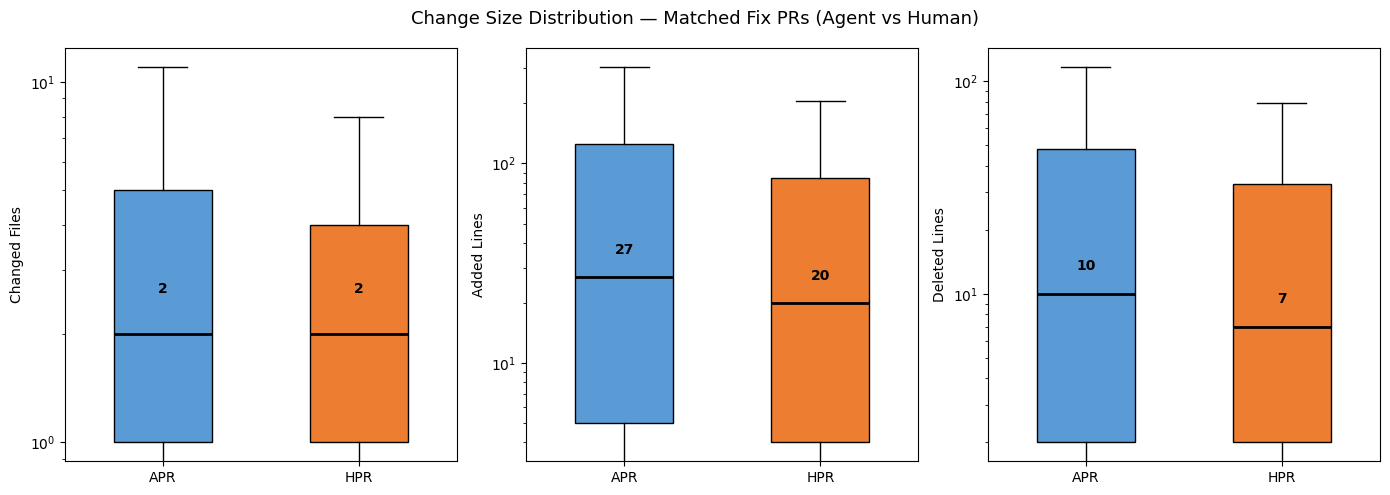

C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\2749861254.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\2749861254.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\2749861254.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,


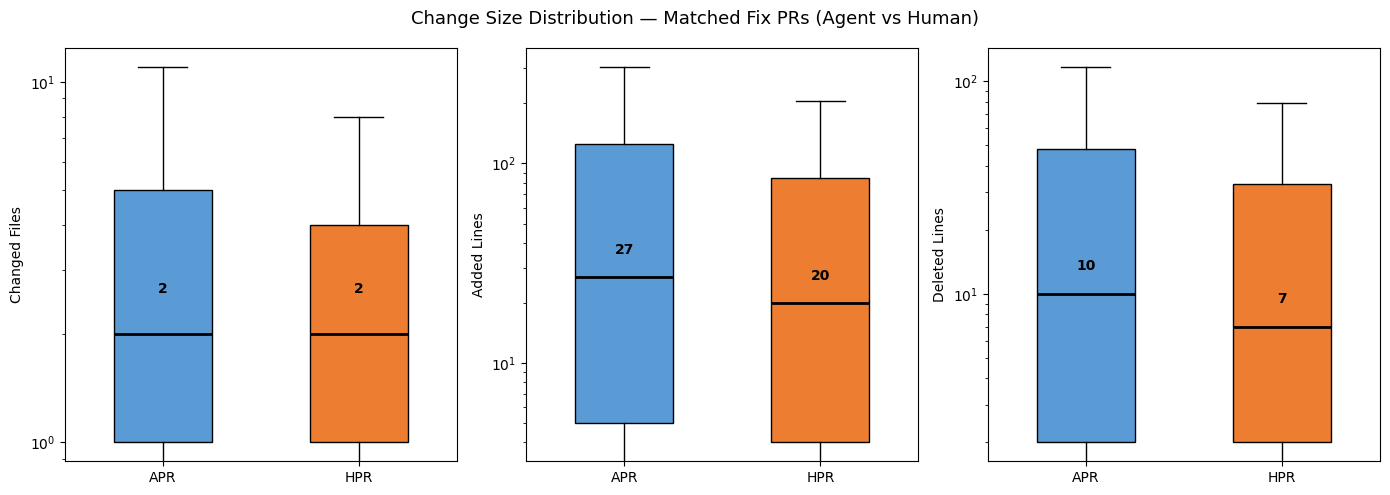

  -> Figure saved: results\matched_report_figures\rq1_change_size.png


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\2749861254.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_desc, labels=["APR", "HPR"], patch_artist=True,


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\2749861254.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\2749861254.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\2749861254.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,


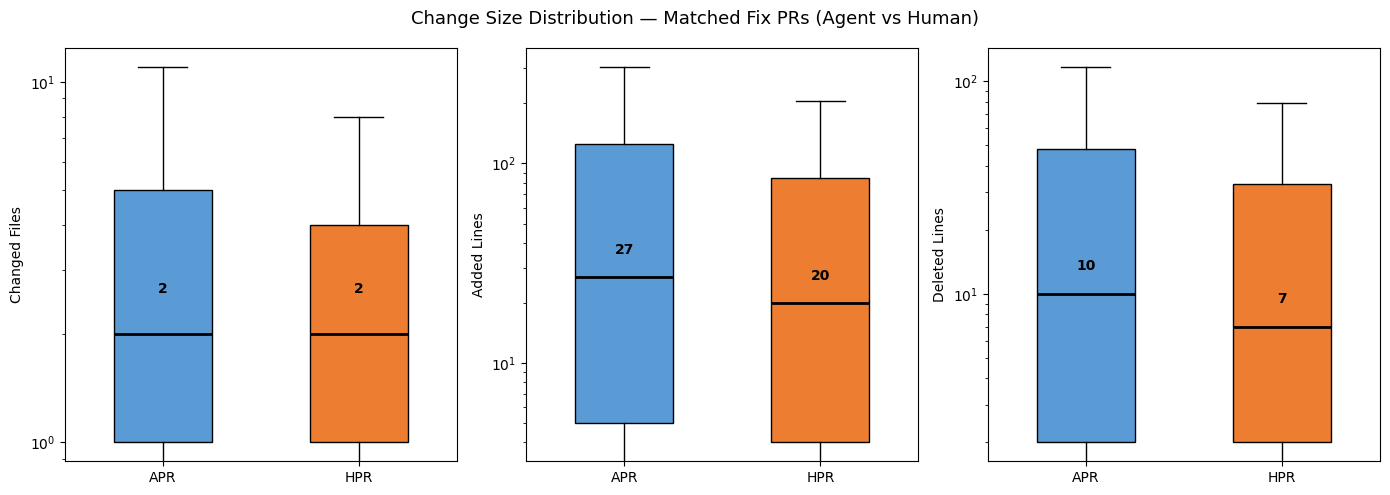

  -> Figure saved: results\matched_report_figures\rq1_change_size.png


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\2749861254.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_desc, labels=["APR", "HPR"], patch_artist=True,


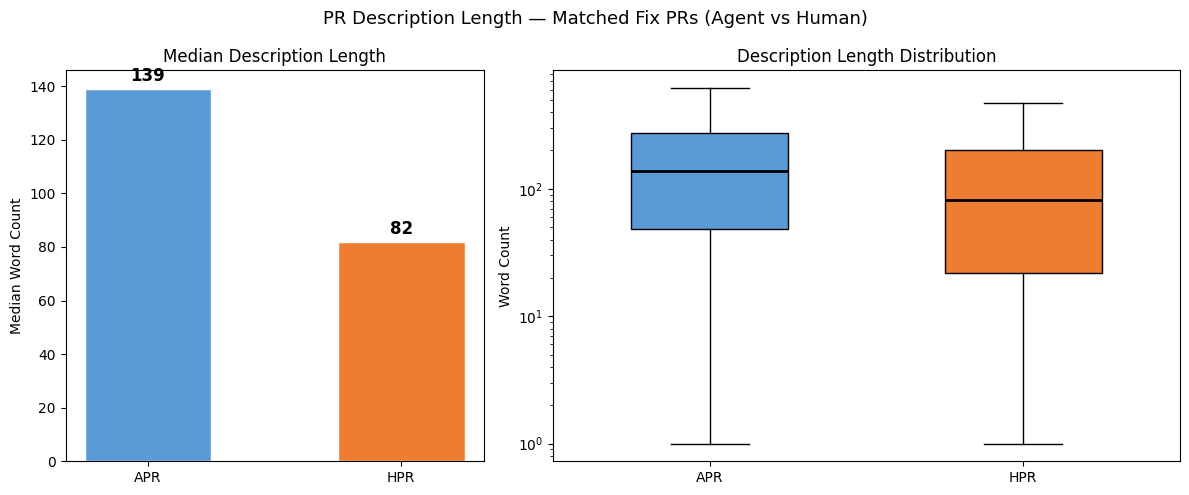

  -> Figure saved: results\matched_report_figures\rq1_description_length.png


In [10]:
# ── Figure 1: Code Change Size — Box plots on log scale ──
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ["files_changed", "lines_added", "lines_deleted"]
titles_m = ["Changed Files", "Added Lines", "Deleted Lines"]

for ax, metric, title in zip(axes, metrics, titles_m):
    data = [
        apr_stats[metric].dropna().values,
        hpr_stats[metric].dropna().values,
    ]
    bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
                    widths=0.5, showfliers=False,
                    medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor("#5b9bd5")
    bp["boxes"][1].set_facecolor("#ed7d31")
    ax.set_yscale("log")
    ax.set_ylabel(title)
    # Annotate medians
    for i, vals in enumerate(data):
        med = np.median(vals)
        ax.text(i + 1, med * 1.3, f"{med:.0f}", ha="center", fontsize=10, fontweight="bold")

fig.suptitle("Change Size Distribution — Matched Fix PRs (Agent vs Human)", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "rq1_change_size.png", dpi=150, bbox_inches="tight")
plt.show()
out(f"  -> Figure saved: {FIG_DIR / 'rq1_change_size.png'}")

# ── Figure 2: PR Description Length ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1.5]})

# Left: bar chart of medians
apr_med = agent_prs["desc_words"].median()
hpr_med = human_prs["desc_words"].median()
bars = axes[0].bar(["APR", "HPR"], [apr_med, hpr_med],
                   color=["#5b9bd5", "#ed7d31"], width=0.5, edgecolor="white")
for bar, val in zip(bars, [apr_med, hpr_med]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                 f"{val:.0f}", ha="center", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Median Word Count")
axes[0].set_title("Median Description Length")

# Right: box plot of full distribution (log scale)
data_desc = [
    agent_prs["desc_words"].clip(lower=1).values,
    human_prs["desc_words"].clip(lower=1).values,
]
bp = axes[1].boxplot(data_desc, labels=["APR", "HPR"], patch_artist=True,
                     widths=0.5, showfliers=False,
                     medianprops=dict(color="black", linewidth=2))
bp["boxes"][0].set_facecolor("#5b9bd5")
bp["boxes"][1].set_facecolor("#ed7d31")
axes[1].set_yscale("log")
axes[1].set_ylabel("Word Count")
axes[1].set_title("Description Length Distribution")

fig.suptitle("PR Description Length — Matched Fix PRs (Agent vs Human)", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "rq1_description_length.png", dpi=150, bbox_inches="tight")
plt.show()
out(f"  -> Figure saved: {FIG_DIR / 'rq1_description_length.png'}")

## RQ2 — Acceptance / Rejection Rates

**To what extent are Agent fix PRs rejected?**

In [11]:
section("RQ2: To what extent are Agent fix PRs rejected?")

def merge_rate(df: pd.DataFrame) -> tuple[int, int, float]:
    merged = df["merged_at"].notna().sum()
    total = len(df)
    return merged, total, merged / total * 100 if total else 0

apr_m, apr_t, apr_r = merge_rate(agent_prs)
hpr_m, hpr_t, hpr_r = merge_rate(human_prs)

out(f"Agent PRs  : {apr_m:,} / {apr_t:,} merged  = {apr_r:.1f}%")
out(f"Human PRs  : {hpr_m:,} / {hpr_t:,} merged  = {hpr_r:.1f}%")

# Chi-squared test on merge rates
contingency = np.array([[apr_m, apr_t - apr_m], [hpr_m, hpr_t - hpr_m]])
if contingency.min() > 0:
    chi2, p_chi, _, _ = sp_stats.chi2_contingency(contingency)
    out(f"Chi-squared test: chi2={chi2:.2f}, p={p_chi:.4f}")
    out(f"  {'Statistically significant' if p_chi < 0.05 else 'Not statistically significant'} at alpha=0.05")

# Merge rate by agent tool
if "agent" in agent_prs.columns:
    out("\nMerge rate by agent tool:")
    for agent_name, grp in agent_prs.groupby("agent"):
        m, t, r = merge_rate(grp)
        out(f"  {agent_name:20s}  {m:>6,} / {t:>6,}  = {r:.1f}%")


  RQ2: To what extent are Agent fix PRs rejected?
Agent PRs  : 38,464 / 46,957 merged  = 81.9%
Human PRs  : 39,977 / 46,957 merged  = 85.1%
Chi-squared test: chi2=176.90, p=0.0000
  Statistically significant at alpha=0.05

Merge rate by agent tool:
  Claude_Code           14,357 / 16,700  = 86.0%
  Copilot                5,059 /  7,955  = 63.6%
  Cursor                17,987 / 20,117  = 89.4%
  Devin                  1,061 /  2,185  = 48.6%


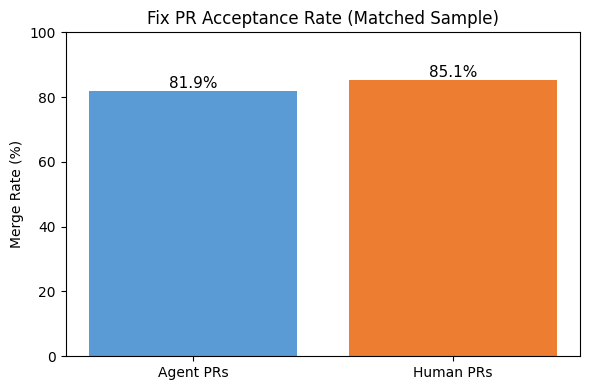


  -> Figure saved: results\matched_report_figures\rq2_merge_rate.png


In [12]:
# Merge rate bar chart
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Agent PRs", "Human PRs"], [apr_r, hpr_r], color=["#5b9bd5", "#ed7d31"])
ax.set_ylabel("Merge Rate (%)")
ax.set_title("Fix PR Acceptance Rate (Matched Sample)")
ax.set_ylim(0, 100)
for bar, val in zip(bars, [apr_r, hpr_r]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{val:.1f}%",
            ha="center", fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / "rq2_merge_rate.png", dpi=150)
plt.show()
out(f"\n  -> Figure saved: {FIG_DIR / 'rq2_merge_rate.png'}")


Agent PRs — median time to merge: 1.42 hours

Human PRs — median time to merge: 5.41 hours



Agent PRs — median time to merge: 1.42 hours

Human PRs — median time to merge: 5.41 hours


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\2910775606.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_ttm, labels=["APR", "HPR"], patch_artist=True,


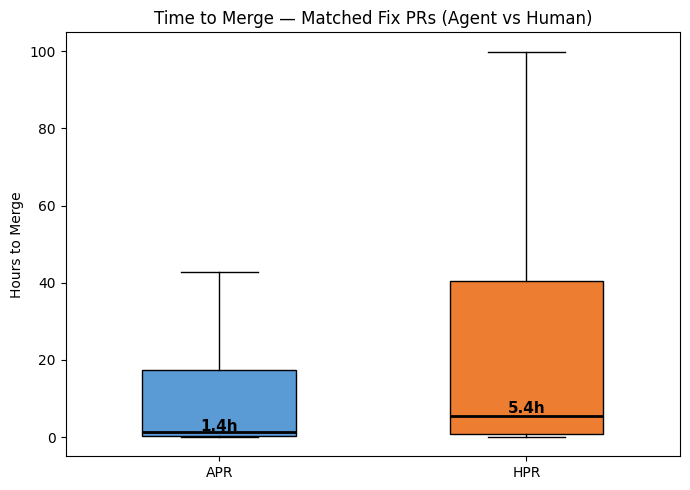

  -> Figure saved: results\matched_report_figures\rq2_time_to_merge.png


In [13]:
# --- Time to merge ---
merge_times = {}
for label, df in [("Agent", agent_prs), ("Human", human_prs)]:
    merged_df = df[df["merged_at"].notna()].copy()
    if len(merged_df) == 0:
        continue
    merged_df["created_dt"] = pd.to_datetime(merged_df["created_at"], utc=True)
    merged_df["merged_dt"] = pd.to_datetime(merged_df["merged_at"], utc=True)
    merged_df["hours_to_merge"] = (merged_df["merged_dt"] - merged_df["created_dt"]).dt.total_seconds() / 3600
    merge_times[label] = merged_df["hours_to_merge"]
    median_h = merged_df["hours_to_merge"].median()
    out(f"\n{label} PRs — median time to merge: {median_h:.2f} hours")

# --- Time to merge box plot ---
fig, ax = plt.subplots(figsize=(7, 5))
data_ttm = [
    merge_times["Agent"].clip(upper=merge_times["Agent"].quantile(0.95)).values,
    merge_times["Human"].clip(upper=merge_times["Human"].quantile(0.95)).values,
]
bp = ax.boxplot(data_ttm, labels=["APR", "HPR"], patch_artist=True,
                widths=0.5, showfliers=False,
                medianprops=dict(color="black", linewidth=2))
bp["boxes"][0].set_facecolor("#5b9bd5")
bp["boxes"][1].set_facecolor("#ed7d31")
for i, vals in enumerate(data_ttm):
    med = np.median(vals)
    ax.text(i + 1, med * 1.15, f"{med:.1f}h", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Hours to Merge")
ax.set_title("Time to Merge — Matched Fix PRs (Agent vs Human)")
fig.tight_layout()
fig.savefig(FIG_DIR / "rq2_time_to_merge.png", dpi=150)
plt.show()
out(f"  -> Figure saved: {FIG_DIR / 'rq2_time_to_merge.png'}")

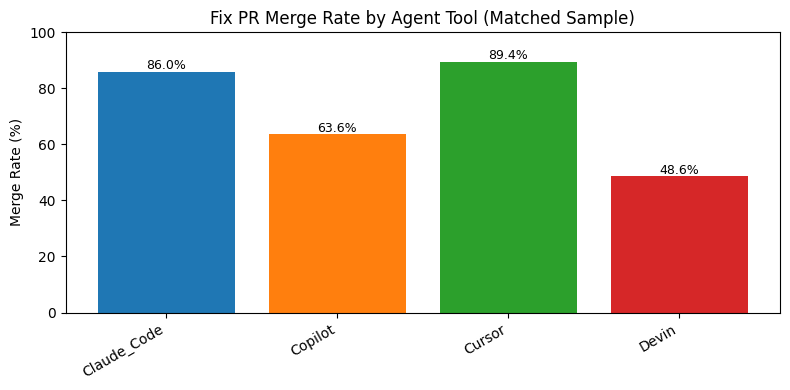

  -> Figure saved: results\matched_report_figures\rq2_merge_rate_by_agent.png


In [14]:
# Merge rate by agent (grouped bar)
if "agent" in agent_prs.columns:
    agent_groups = agent_prs.groupby("agent")
    agents_list = sorted(agent_groups.groups.keys())
    merge_rates = []
    for a in agents_list:
        grp = agent_groups.get_group(a)
        _, _, r = merge_rate(grp)
        merge_rates.append(r)

    fig, ax = plt.subplots(figsize=(8, 4))
    colors = sns.color_palette("tab10", len(agents_list))
    ax.bar(agents_list, merge_rates, color=colors)
    ax.set_ylabel("Merge Rate (%)")
    ax.set_title("Fix PR Merge Rate by Agent Tool (Matched Sample)")
    ax.set_ylim(0, 100)
    for i, (a, r) in enumerate(zip(agents_list, merge_rates)):
        ax.text(i, r + 1, f"{r:.1f}%", ha="center", fontsize=9)
    plt.xticks(rotation=30, ha="right")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "rq2_merge_rate_by_agent.png", dpi=150)
    plt.show()
    out(f"  -> Figure saved: {FIG_DIR / 'rq2_merge_rate_by_agent.png'}")

C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\3101710130.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  all_prs["created_month_rq2"] = pd.to_datetime(all_prs["created_at"], utc=True).dt.to_period("M")


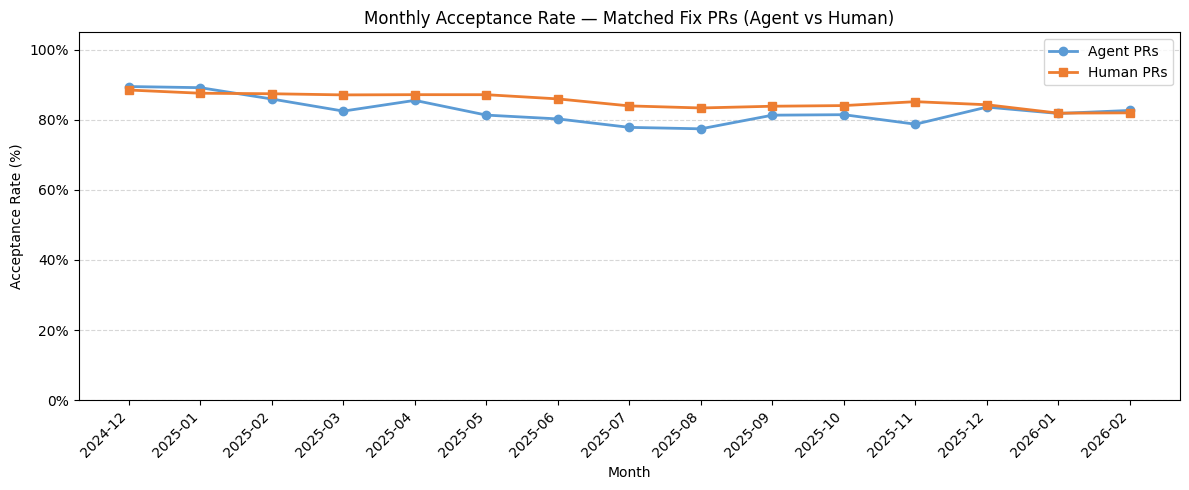


  -> Figure saved: results\matched_report_figures\rq2_monthly_acceptance_rate.png


In [28]:
# ── Figure: Monthly Acceptance Rate — Agent vs Human ──
all_prs["created_month_rq2"] = pd.to_datetime(all_prs["created_at"], utc=True).dt.to_period("M")
all_prs["is_merged"] = all_prs["merged_at"].notna()

monthly_accept = (
    all_prs.groupby(["created_month_rq2", "source"])["is_merged"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "merged", "count": "total"})
    .reset_index()
)
monthly_accept["acceptance_rate"] = monthly_accept["merged"] / monthly_accept["total"] * 100

agent_monthly = monthly_accept[monthly_accept["source"] == "agent"].sort_values("created_month_rq2")
human_monthly = monthly_accept[monthly_accept["source"] == "human"].sort_values("created_month_rq2")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(agent_monthly["created_month_rq2"].astype(str), agent_monthly["acceptance_rate"],
        "o-", label="Agent PRs", color="#5b9bd5", linewidth=2, markersize=6)
ax.plot(human_monthly["created_month_rq2"].astype(str), human_monthly["acceptance_rate"],
        "s-", label="Human PRs", color="#ed7d31", linewidth=2, markersize=6)
ax.set_xlabel("Month")
ax.set_ylabel("Acceptance Rate (%)")
ax.set_title("Monthly Acceptance Rate — Matched Fix PRs (Agent vs Human)")
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig(FIG_DIR / "rq2_monthly_acceptance_rate.png", dpi=150, bbox_inches="tight")
plt.show()
out(f"\n  -> Figure saved: {FIG_DIR / 'rq2_monthly_acceptance_rate.png'}")

In [33]:
# ── Diagnostic: verify monthly acceptance rate numbers ──
print(f"Overall acceptance rates (from RQ2):")
print(f"  Agent: {apr_r:.1f}%  ({apr_m}/{apr_t})")
print(f"  Human: {hpr_r:.1f}%  ({hpr_m}/{hpr_t})")

print(f"\nMonthly breakdown (agent):")
print(agent_monthly[["created_month_rq2", "merged", "total", "acceptance_rate"]].to_string(index=False))

print(f"\nMonthly breakdown (human):")
print(human_monthly[["created_month_rq2", "merged", "total", "acceptance_rate"]].to_string(index=False))

# Sanity check: weighted avg should match overall
agent_weighted = agent_monthly["merged"].sum() / agent_monthly["total"].sum() * 100
human_weighted = human_monthly["merged"].sum() / human_monthly["total"].sum() * 100
print(f"\nWeighted avg from monthly data: Agent={agent_weighted:.1f}%  Human={human_weighted:.1f}%")
print(f"Match overall?  Agent: {'YES' if abs(agent_weighted - apr_r) < 0.1 else 'NO'}  Human: {'YES' if abs(human_weighted - hpr_r) < 0.1 else 'NO'}")

Overall acceptance rates (from RQ2):
  Agent: 81.9%  (38464/46957)
  Human: 85.1%  (39977/46957)

Monthly breakdown (agent):
created_month_rq2  merged  total  acceptance_rate
          2024-12    1701   1900        89.526316
          2025-01    1726   1935        89.198966
          2025-02    1837   2137        85.961628
          2025-03    2118   2567        82.508765
          2025-04    2189   2558        85.574668
          2025-05    2489   3059        81.366460
          2025-06    3151   3925        80.280255
          2025-07    3792   4870        77.864476
          2025-08    2686   3468        77.450980
          2025-09    2669   3281        81.347150
          2025-10    2566   3149        81.486186
          2025-11    2493   3165        78.767773
          2025-12    2503   2992        83.656417
          2026-01    2978   3639        81.835669
          2026-02    3566   4312        82.699443

Monthly breakdown (human):
created_month_rq2  merged  total  acceptance_ra

C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\3016552386.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  ).dt.to_period("M")


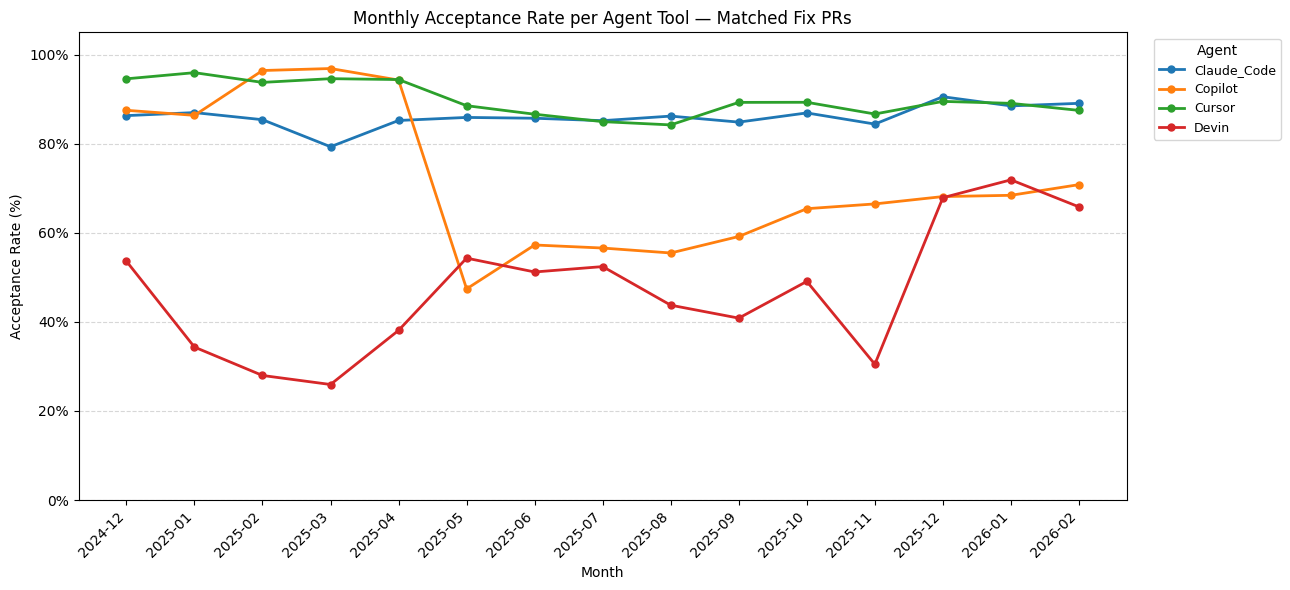


  -> Figure saved: results\matched_report_figures\rq2_monthly_acceptance_rate_per_agent.png


In [29]:
# ── Figure: Monthly Acceptance Rate — Per Agent Tool ──
if "agent" in agent_prs.columns:
    agent_prs_monthly = agent_prs.copy()
    agent_prs_monthly["created_month_rq2"] = pd.to_datetime(
        agent_prs_monthly["created_at"], utc=True
    ).dt.to_period("M")
    agent_prs_monthly["is_merged"] = agent_prs_monthly["merged_at"].notna()

    per_agent_monthly = (
        agent_prs_monthly.groupby(["created_month_rq2", "agent"])["is_merged"]
        .agg(["sum", "count"])
        .rename(columns={"sum": "merged", "count": "total"})
        .reset_index()
    )
    per_agent_monthly["acceptance_rate"] = (
        per_agent_monthly["merged"] / per_agent_monthly["total"] * 100
    )

    agent_names = sorted(per_agent_monthly["agent"].unique())
    palette = sns.color_palette("tab10", len(agent_names))

    fig, ax = plt.subplots(figsize=(13, 6))
    for agent_tool, color in zip(agent_names, palette):
        subset = per_agent_monthly[per_agent_monthly["agent"] == agent_tool].sort_values("created_month_rq2")
        ax.plot(
            subset["created_month_rq2"].astype(str),
            subset["acceptance_rate"],
            "o-", label=agent_tool, color=color, linewidth=2, markersize=5,
        )

    ax.set_xlabel("Month")
    ax.set_ylabel("Acceptance Rate (%)")
    ax.set_title("Monthly Acceptance Rate per Agent Tool — Matched Fix PRs")
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(title="Agent", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.xticks(rotation=45, ha="right")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "rq2_monthly_acceptance_rate_per_agent.png", dpi=150, bbox_inches="tight")
    plt.show()
    out(f"\n  -> Figure saved: {FIG_DIR / 'rq2_monthly_acceptance_rate_per_agent.png'}")

In [27]:
# ── Table 2 (replication): Acceptance and merge time statistics of PRs ──
#  merged = accepted, closed-but-unmerged = rejected.
# Open PRs already excluded at data loading.

from lifelines.statistics import logrank_test

def compute_row(label, df):
    """Compute stats: merged=accepted, closed-unmerged=rejected."""
    accepted = int(df["merged_at"].notna().sum())
    rejected = int(df["merged_at"].isna().sum())
    total = accepted + rejected
    pct = accepted / total * 100 if total else 0
    merged = df[df["merged_at"].notna()].copy()
    if len(merged):
        merged["hours"] = (
            pd.to_datetime(merged["merged_at"], utc=True)
            - pd.to_datetime(merged["created_at"], utc=True)
        ).dt.total_seconds() / 3600
        med_hours = merged["hours"].median()
    else:
        med_hours = float("nan")
    return [label, f"{accepted:,}", f"{rejected:,}", f"{total:,}", f"{pct:.1f}%", f"{med_hours:.2f}"]

rows = [
    compute_row("APRs", agent_prs),
    compute_row("HPRs", human_prs),
]

# Per-agent breakdown
if "agent" in agent_prs.columns:
    for agent_name in sorted(agent_prs["agent"].unique()):
        rows.append(compute_row(f"  APR \u2013 {agent_name}", agent_prs[agent_prs["agent"] == agent_name]))

summary_df = pd.DataFrame(rows, columns=["Category", "#Accepted", "#Rejected", "#Total", "%Acceptance", "Median Time to Merge"])
print("Table 2. Acceptance and merge time statistics of PRs (Matched Sample).\n")
display(summary_df)

# ── Chi-squared test on acceptance rates ──
apr_acc = int(agent_prs["merged_at"].notna().sum())
apr_rej = int(agent_prs["merged_at"].isna().sum())
hpr_acc = int(human_prs["merged_at"].notna().sum())
hpr_rej = int(human_prs["merged_at"].isna().sum())
contingency = np.array([[apr_acc, apr_rej], [hpr_acc, hpr_rej]])
chi2, p_chi, _, _ = sp_stats.chi2_contingency(contingency)
print(f"\nChi-squared test (acceptance): \u03c7\u00b2={chi2:.2f}, p={p_chi:.6f}")
print(f"  \u2192 {'Statistically significant' if p_chi < 0.05 else 'Not significant'} at \u03b1=0.05")

# ── Log-rank test on merge times ──
def hours_to_merge(df):
    tmp = df.copy()
    tmp["merged"] = tmp["merged_at"].notna().astype(int)
    tmp["hours"] = (
        pd.to_datetime(tmp["closed_at"], utc=True)
        - pd.to_datetime(tmp["created_at"], utc=True)
    ).dt.total_seconds() / 3600
    return tmp["hours"].values, tmp["merged"].values

apr_time, apr_event = hours_to_merge(agent_prs)
hpr_time, hpr_event = hours_to_merge(human_prs)

lr = logrank_test(apr_time, hpr_time, event_observed_A=apr_event, event_observed_B=hpr_event)
print(f"\nLog-rank test (merge time): test_statistic={lr.test_statistic:.2f}, p={lr.p_value:.6f}")
print(f"  \u2192 {'Significant difference' if lr.p_value < 0.05 else 'No significant difference'} in merge times at \u03b1=0.05")

Table 2. Acceptance and merge time statistics of PRs (Matched Sample).



,Category,#Accepted,#Rejected,#Total,%Acceptance,Median Time to Merge
0,APRs,"38,464","8,493","46,957",81.9%,1.42
1,HPRs,"39,977","6,980","46,957",85.1%,5.41
2,APR – Claude_Code,"14,357","2,343","16,700",86.0%,1.49
3,APR – Copilot,"5,059","2,896","7,955",63.6%,11.56
4,APR – Cursor,"17,987","2,130","20,117",89.4%,0.82
5,APR – Devin,"1,061","1,124","2,185",48.6%,2.18



Chi-squared test (acceptance): χ²=176.90, p=0.000000
  → Statistically significant at α=0.05

Log-rank test (merge time): test_statistic=629.33, p=0.000000
  → Significant difference in merge times at α=0.05


## RQ3 — Revisions

**What proportion of fix PRs are accepted without revisions?**

In [17]:
section("RQ3: What proportion of fix PRs are accepted without revisions?")

# Count commits per PR
commits_per_pr = commits.groupby("pr_id").size().reset_index(name="num_commits")

apr_commits = commits_per_pr[commits_per_pr["pr_id"].isin(agent_ids)]
hpr_commits = commits_per_pr[commits_per_pr["pr_id"].isin(human_ids)]

# Merged PRs only
merged_agent_ids = set(agent_prs[agent_prs["merged_at"].notna()]["id"])
merged_human_ids = set(human_prs[human_prs["merged_at"].notna()]["id"])

apr_merged_commits = apr_commits[apr_commits["pr_id"].isin(merged_agent_ids)]
hpr_merged_commits = hpr_commits[hpr_commits["pr_id"].isin(merged_human_ids)]

apr_single = (apr_merged_commits["num_commits"] == 1).sum()
hpr_single = (hpr_merged_commits["num_commits"] == 1).sum()
apr_total_merged = len(apr_merged_commits)
hpr_total_merged = len(hpr_merged_commits)

apr_single_pct = apr_single / apr_total_merged * 100 if apr_total_merged else 0
hpr_single_pct = hpr_single / hpr_total_merged * 100 if hpr_total_merged else 0

out(f"Merged without revision (single commit):")
out(f"  Agent PRs : {apr_single:,} / {apr_total_merged:,} = {apr_single_pct:.1f}%")
out(f"  Human PRs : {hpr_single:,} / {hpr_total_merged:,} = {hpr_single_pct:.1f}%")

# Revision commit count distribution (for PRs with >1 commit)
apr_revised = apr_merged_commits[apr_merged_commits["num_commits"] > 1]
hpr_revised = hpr_merged_commits[hpr_merged_commits["num_commits"] > 1]

out(f"\nRevised PRs (>1 commit):")
out(f"  Agent PRs : {len(apr_revised):,}  median commits: {apr_revised['num_commits'].median():.0f}" if len(apr_revised) else "  Agent PRs : 0")
out(f"  Human PRs : {len(hpr_revised):,}  median commits: {hpr_revised['num_commits'].median():.0f}" if len(hpr_revised) else "  Human PRs : 0")

# Mann-Whitney U test on revision counts
if len(apr_revised) > 0 and len(hpr_revised) > 0:
    u_stat, p_val = sp_stats.mannwhitneyu(
        apr_revised["num_commits"], hpr_revised["num_commits"], alternative="two-sided"
    )
    out(f"  Mann-Whitney U: U={u_stat:.0f}, p={p_val:.4f}")
    out(f"  {'Statistically significant' if p_val < 0.05 else 'Not statistically significant'} at alpha=0.05")


  RQ3: What proportion of fix PRs are accepted without revisions?
Merged without revision (single commit):
  Agent PRs : 13,599 / 27,832 = 48.9%
  Human PRs : 14,477 / 29,109 = 49.7%

Revised PRs (>1 commit):
  Agent PRs : 14,233  median commits: 3
  Human PRs : 14,632  median commits: 3
  Mann-Whitney U: U=101961267, p=0.0016
  Statistically significant at alpha=0.05


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\2926839412.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_rev, labels=labels_rev, patch_artist=True,


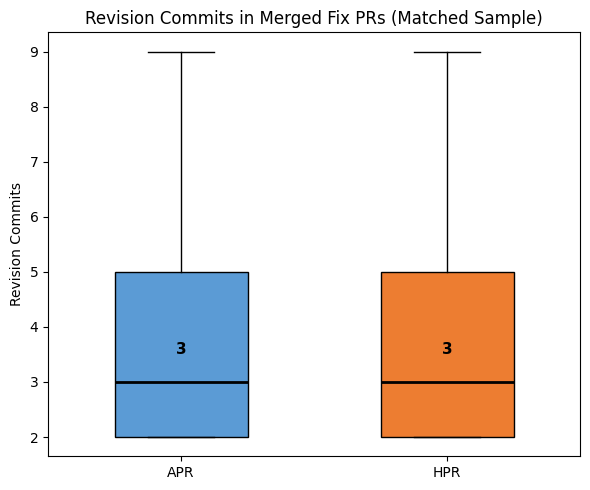


  -> Figure saved: results\matched_report_figures\rq3_revision_commits.png


In [18]:
# Revision count — box plot
fig, ax = plt.subplots(figsize=(6, 5))
data_rev = []
labels_rev = []
if len(apr_revised):
    data_rev.append(apr_revised["num_commits"].clip(upper=50).values)
    labels_rev.append("APR")
if len(hpr_revised):
    data_rev.append(hpr_revised["num_commits"].clip(upper=50).values)
    labels_rev.append("HPR")
if data_rev:
    bp = ax.boxplot(data_rev, labels=labels_rev, patch_artist=True,
                    widths=0.5, showfliers=False,
                    medianprops=dict(color="black", linewidth=2))
    colors = ["#5b9bd5", "#ed7d31"]
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
    for i, vals in enumerate(data_rev):
        med = np.median(vals)
        ax.text(i + 1, med + 0.5, f"{med:.0f}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Revision Commits")
ax.set_title("Revision Commits in Merged Fix PRs (Matched Sample)")
fig.tight_layout()
fig.savefig(FIG_DIR / "rq3_revision_commits.png", dpi=150)
plt.show()
out(f"\n  -> Figure saved: {FIG_DIR / 'rq3_revision_commits.png'}")

In [19]:
# Revision change size (files, lines) for revised PRs
# For revised PRs, compute stats from commits after the first one
def initial_and_revision_stats(revised_pr_ids: set, commits_df: pd.DataFrame, details_df: pd.DataFrame):
    """Get change stats for initial commit and revision commits separately."""
    pr_commits_ordered = commits_df[commits_df["pr_id"].isin(revised_pr_ids)].copy()
    first_commits = pr_commits_ordered.groupby("pr_id").first().reset_index()
    first_shas = set(first_commits["sha"])

    # Initial commit stats
    init_details = details_df[details_df["sha"].isin(first_shas)]
    init_stats = init_details.groupby("pr_id").agg(
        init_files=("filename", "nunique"),
        init_added=("additions", "sum"),
        init_deleted=("deletions", "sum"),
    ).reset_index()
    init_stats["init_total_changes"] = init_stats["init_added"] + init_stats["init_deleted"]

    # Revision commit stats (all non-first commits)
    rev_shas = set(pr_commits_ordered["sha"]) - first_shas
    rev_details = details_df[details_df["sha"].isin(rev_shas)]
    rev_stats = rev_details.groupby("pr_id").agg(
        rev_files_changed=("filename", "nunique"),
        rev_lines_added=("additions", "sum"),
        rev_lines_deleted=("deletions", "sum"),
    ).reset_index()
    rev_stats["rev_total_changes"] = rev_stats["rev_lines_added"] + rev_stats["rev_lines_deleted"]

    # Merge and compute metric (4): % of code modification vs initial submission
    merged = rev_stats.merge(init_stats[["pr_id", "init_total_changes"]], on="pr_id", how="left")
    merged["pct_modification"] = (
        merged["rev_total_changes"] / merged["init_total_changes"].replace(0, np.nan) * 100
    )
    return merged

apr_rev_ids = set(apr_revised["pr_id"])
hpr_rev_ids = set(hpr_revised["pr_id"])

if apr_rev_ids or hpr_rev_ids:
    apr_rev_stats = initial_and_revision_stats(apr_rev_ids, commits, details) if apr_rev_ids else pd.DataFrame()
    hpr_rev_stats = initial_and_revision_stats(hpr_rev_ids, commits, details) if hpr_rev_ids else pd.DataFrame()

    out("\nRevision effort (median, revised PRs only):")
    out("  Metric (2) - Files changed in revisions:")
    a_med = apr_rev_stats["rev_files_changed"].median() if len(apr_rev_stats) else 0
    h_med = hpr_rev_stats["rev_files_changed"].median() if len(hpr_rev_stats) else 0
    out(f"    APR: {a_med:.0f}   HPR: {h_med:.0f}")

    out("  Metric (3) - Lines added/deleted in revisions:")
    for metric in ["rev_lines_added", "rev_lines_deleted"]:
        a_med = apr_rev_stats[metric].median() if len(apr_rev_stats) else 0
        h_med = hpr_rev_stats[metric].median() if len(hpr_rev_stats) else 0
        out(f"    {metric:<25s}  APR: {a_med:>8.0f}   HPR: {h_med:>8.0f}")

    out("  Metric (4) - % code modification vs initial submission:")
    a_pct = apr_rev_stats["pct_modification"].median() if len(apr_rev_stats) else 0
    h_pct = hpr_rev_stats["pct_modification"].median() if len(hpr_rev_stats) else 0
    out(f"    APR: {a_pct:.1f}%   HPR: {h_pct:.1f}%")


Revision effort (median, revised PRs only):
  Metric (2) - Files changed in revisions:
    APR: 2   HPR: 2
  Metric (3) - Lines added/deleted in revisions:
    rev_lines_added            APR:       18   HPR:       10
    rev_lines_deleted          APR:       10   HPR:        6
  Metric (4) - % code modification vs initial submission:
    APR: 79.6%   HPR: 81.8%


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\1453451127.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\1453451127.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\1453451127.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\1453451127.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\1453451127.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\1453451127.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,


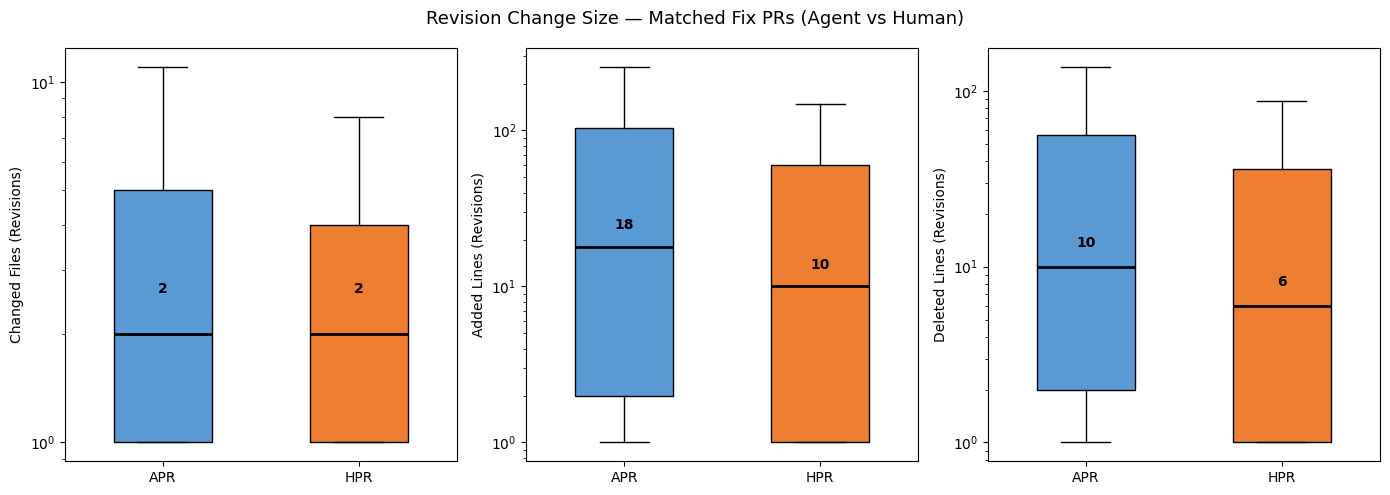

  -> Figure saved: results\matched_report_figures\rq3_revision_change_size.png


In [20]:
# Revision change size — box plots on log scale
if apr_rev_ids or hpr_rev_ids:
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    rev_metrics = ["rev_files_changed", "rev_lines_added", "rev_lines_deleted"]
    rev_titles = ["Changed Files (Revisions)", "Added Lines (Revisions)", "Deleted Lines (Revisions)"]
    for ax, metric, title in zip(axes, rev_metrics, rev_titles):
        apr_vals = apr_rev_stats[metric].dropna().clip(lower=1).values if len(apr_rev_stats) else np.array([])
        hpr_vals = hpr_rev_stats[metric].dropna().clip(lower=1).values if len(hpr_rev_stats) else np.array([])
        data = [apr_vals, hpr_vals]
        bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
                        widths=0.5, showfliers=False,
                        medianprops=dict(color="black", linewidth=2))
        bp["boxes"][0].set_facecolor("#5b9bd5")
        bp["boxes"][1].set_facecolor("#ed7d31")
        ax.set_yscale("log")
        ax.set_ylabel(title)
        for i, vals in enumerate(data):
            if len(vals):
                med = np.median(vals)
                ax.text(i + 1, med * 1.3, f"{med:.0f}", ha="center", fontsize=10, fontweight="bold")
    fig.suptitle("Revision Change Size — Matched Fix PRs (Agent vs Human)", fontsize=13)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "rq3_revision_change_size.png", dpi=150, bbox_inches="tight")
    plt.show()
    out(f"  -> Figure saved: {FIG_DIR / 'rq3_revision_change_size.png'}")

## Additional Statistics

In [21]:
section("Additional Statistics")

# PR state breakdown
out("PR state breakdown:")
for label, df in [("Agent", agent_prs), ("Human", human_prs)]:
    out(f"  {label}:")
    for state, cnt in df["state"].value_counts().items():
        out(f"    {state:12s} {cnt:>8,}")


  Additional Statistics
PR state breakdown:
  Agent:
    closed         46,957
  Human:
    closed         46,957


In [22]:
# Monthly trends
all_prs["created_month"] = pd.to_datetime(all_prs["created_at"], utc=True).dt.to_period("M")
monthly = all_prs.groupby(["created_month", "is_agent"]).size().unstack(fill_value=0)
monthly.columns = ["Human", "Agent"] if False in monthly.columns else monthly.columns

out("\nMonthly PR volume:")
out(f"{'Month':<12} {'Agent':>8} {'Human':>8} {'Total':>8}")
out("-" * 40)
for period in monthly.index:
    row = monthly.loc[period]
    agent_val = row.get(True, row.get("Agent", 0))
    human_val = row.get(False, row.get("Human", 0))
    total = agent_val + human_val
    out(f"{str(period):<12} {int(agent_val):>8,} {int(human_val):>8,} {int(total):>8,}")


Monthly PR volume:
Month           Agent    Human    Total
----------------------------------------
2024-12         1,900    2,406    4,306
2025-01         1,935    2,640    4,575
2025-02         2,137    2,856    4,993
2025-03         2,567    3,125    5,692
2025-04         2,558    3,016    5,574
2025-05         3,059    2,991    6,050
2025-06         3,925    3,063    6,988
2025-07         4,870    3,499    8,369
2025-08         3,468    3,061    6,529
2025-09         3,281    3,137    6,418
2025-10         3,149    3,406    6,555
2025-11         3,165    3,156    6,321
2025-12         2,992    3,164    6,156
2026-01         3,639    3,590    7,229
2026-02         4,312    3,847    8,159


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_4344\259854839.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  all_prs["created_month"] = pd.to_datetime(all_prs["created_at"], utc=True).dt.to_period("M")


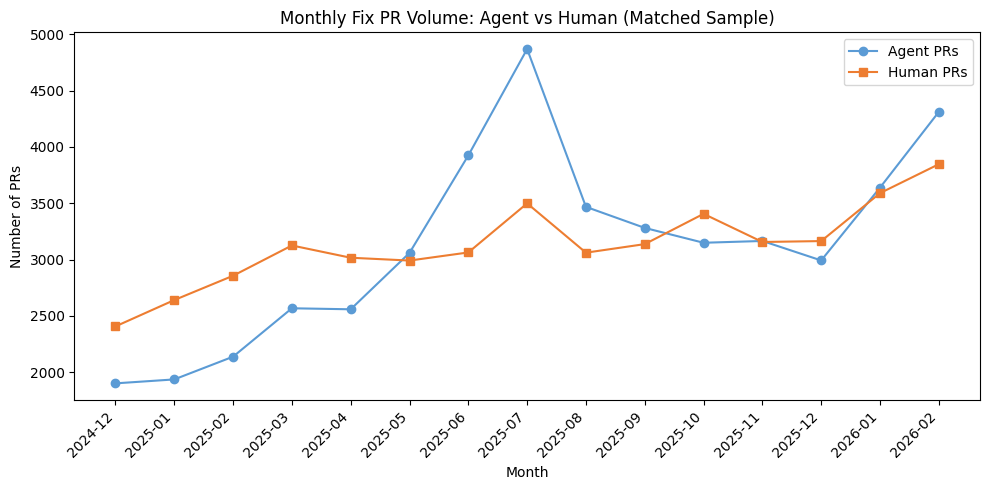


  -> Figure saved: results\matched_report_figures\monthly_trend.png


In [23]:
# Monthly trend chart
fig, ax = plt.subplots(figsize=(10, 5))
months_str = [str(p) for p in monthly.index]
agent_vals = [monthly.loc[p].get(True, monthly.loc[p].get("Agent", 0)) for p in monthly.index]
human_vals = [monthly.loc[p].get(False, monthly.loc[p].get("Human", 0)) for p in monthly.index]
ax.plot(months_str, agent_vals, "o-", label="Agent PRs", color="#5b9bd5")
ax.plot(months_str, human_vals, "s-", label="Human PRs", color="#ed7d31")
ax.set_xlabel("Month")
ax.set_ylabel("Number of PRs")
ax.set_title("Monthly Fix PR Volume: Agent vs Human (Matched Sample)")
ax.legend()
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig(FIG_DIR / "monthly_trend.png", dpi=150)
plt.show()
out(f"\n  -> Figure saved: {FIG_DIR / 'monthly_trend.png'}")

In [24]:
# Top repositories
out("\nTop 10 repos by total PRs:")
top_repos = all_prs["repo_name"].value_counts().head(10)
for repo, cnt in top_repos.items():
    agent_cnt = len(all_prs[(all_prs["repo_name"] == repo) & (all_prs["is_agent"] == True)])
    out(f"  {repo:50s}  total: {cnt:>5,}  agent: {agent_cnt:>5,}")


Top 10 repos by total PRs:
  getsentry/sentry                                    total: 2,500  agent: 1,566
  BerriAI/litellm                                     total: 1,611  agent: 1,159
  PostHog/posthog                                     total: 1,424  agent:   134
  StarRocks/starrocks                                 total: 1,394  agent:   162
  elastic/kibana                                      total: 1,375  agent:    73
  grafana/loki                                        total: 1,101  agent:   918
  microsoft/vscode                                    total: 1,052  agent:   468
  promptfoo/promptfoo                                 total:   984  agent:   893
  zed-industries/zed                                  total:   872  agent:   367
  vllm-project/vllm                                   total:   859  agent:    19


## Save Report

In [25]:
REPORT_PATH.write_text("\n".join(report_lines), encoding="utf-8")
print(f"\nReport saved to {REPORT_PATH}")
print(f"Figures saved to {FIG_DIR}/")
print("Done!")


Report saved to results\matched_report.txt
Figures saved to results\matched_report_figures/
Done!
